# Exploratory Data Analysis: Stanford Dogs Dataset

**Course:** MAI202 – Deep Learning  
**Project:** Dog Breed Classification with Out-of-Distribution Detection  
**Notebook:** `01_eda.ipynb`  
**Author:** Soodeh Vanaki  

## Objective

This notebook presents an exploratory analysis of the Stanford Dogs dataset before model training.

The purpose is to understand the dataset characteristics and identify preprocessing, augmentation, and modeling considerations for the ResNet-18 dog-breed classifier.

The analysis focuses on:

1. Dataset structure and breed coverage
2. Class-distribution characteristics
3. Representative dog-breed images
4. Image-size and aspect-ratio variability
5. Bounding-box cropping considerations
6. Potential class-imbalance concerns
7. Recommendations for preprocessing and model training

In [1]:
import sys
import platform
import pandas as pd
import matplotlib

print("=" * 60)
print("Environment Information")
print("=" * 60)
print(f"Python Version      : {sys.version.split()[0]}")
print(f"Operating System    : {platform.system()} {platform.release()}")
print(f"Pandas Version      : {pd.__version__}")
print(f"Matplotlib Version  : {matplotlib.__version__}")
print("=" * 60)

Environment Information
Python Version      : 3.11.15
Operating System    : Windows 10
Pandas Version      : 2.3.3
Matplotlib Version  : 3.11.1


### Import Libraries

In [2]:
from pathlib import Path
import random
from collections import Counter

import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# Make notebook outputs reproducible
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Imports completed successfully.")

Imports completed successfully.


In [3]:
# a function to convert a Stanford Dogs folder name into a readable breed name
def get_breed_name(breed_path):
    """
    Convert a Stanford Dogs folder name into a readable breed name.

    Example:
        n02085620-Chihuahua -> Chihuahua
        n02088466_bloodhound -> bloodhound
    """
    return breed_path.name.split("-", 1)[1].replace("_", " ")

### Project Path Configuration

In [4]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

IMAGES_DIR = RAW_DATA_DIR / "Images"
ANNOTATIONS_DIR = RAW_DATA_DIR / "Annotation"
LISTS_DIR = RAW_DATA_DIR / "lists"

EDA_PLOTS_DIR = PROJECT_ROOT / "reports" / "eda_plots"
EDA_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images:", IMAGES_DIR)
print("Annotations:", ANNOTATIONS_DIR)
print("Lists:", LISTS_DIR)

Project root: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector
Images: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Images
Annotations: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Annotation
Lists: c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\lists


### Verify the dataset

In [5]:
for folder in [IMAGES_DIR, ANNOTATIONS_DIR, LISTS_DIR]:
    print(f"{folder.name}: {folder.exists()}")

Images: True
Annotation: True
lists: True


### Count breeds

In [6]:
breed_folders = sorted([d for d in IMAGES_DIR.iterdir() if d.is_dir()])

print("Number of breeds:", len(breed_folders))
print()

print("First 10 breeds:")

for breed in breed_folders[:10]:
    print("-", breed.name)

Number of breeds: 120

First 10 breeds:
- n02085620-Chihuahua
- n02085782-Japanese_spaniel
- n02085936-Maltese_dog
- n02086079-Pekinese
- n02086240-Shih-Tzu
- n02086646-Blenheim_spaniel
- n02086910-papillon
- n02087046-toy_terrier
- n02087394-Rhodesian_ridgeback
- n02088094-Afghan_hound


### Count images per breed

In [7]:
breed_counts = []

for breed in breed_folders:
    image_count = len(list(breed.glob("*.jpg")))
    breed_counts.append(
        {
            "Breed": breed.name,
            "Images": image_count
        }
    )

breed_df = pd.DataFrame(breed_counts)

breed_df.head()

,Breed,Images
0,n02085620-Chihuahua,152
1,n02085782-Japanese_spaniel,185
2,n02085936-Maltese_dog,252
3,n02086079-Pekinese,149
4,n02086240-Shih-Tzu,214


## Dataset Overview

The Stanford Dogs dataset is a benchmark dataset designed for fine-grained image classification. Unlike general object classification tasks, fine-grained classification requires distinguishing between visually similar categories. In this project, the model must correctly classify images into one of 120 dog breeds despite variations in pose, lighting, background, image quality, and camera perspective.

The objective of this exploratory data analysis (EDA) is to understand the characteristics of the dataset before model development. The findings from this analysis will guide preprocessing decisions, data augmentation strategies, and model training.

The EDA focuses on the following aspects:

- Dataset structure and organization
- Breed (class) distribution
- Representative image samples
- Image dimensions and aspect ratios
- Bounding-box annotations
- Dataset challenges and preprocessing considerations

### Dataset Information

In [8]:
# Summary Statistics
total_breeds = len(breed_folders)
total_images = breed_df["Images"].sum()

print(f"Number of breeds : {total_breeds}")
print(f"Total images     : {total_images}")

Number of breeds : 120
Total images     : 20580


In [9]:
# Dataset Summary
dataset_summary = pd.DataFrame(
    {
        "Metric": [
            "Number of Classes",
            "Total Images",
            "Average Images per Breed",
            "Minimum Images per Breed",
            "Maximum Images per Breed",
        ],
        "Value": [
            total_breeds,
            total_images,
            round(breed_df["Images"].mean(), 2),
            breed_df["Images"].min(),
            breed_df["Images"].max(),
        ],
    }
)

dataset_summary

,Metric,Value
0,Number of Classes,120.0
1,Total Images,20580.0
2,Average Images per Breed,171.5
3,Minimum Images per Breed,148.0
4,Maximum Images per Breed,252.0


### Dataset Organization

In [10]:
# Dataset Structure
print("Dataset Structure")

print(f"Images Directory      : {IMAGES_DIR}")
print(f"Annotations Directory : {ANNOTATIONS_DIR}")
print(f"Lists Directory       : {LISTS_DIR}")

Dataset Structure
Images Directory      : c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Images
Annotations Directory : c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Annotation
Lists Directory       : c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\lists


### Observations

- The dataset contains **120 dog breeds** represented by **20,580 images**.
- Images are organized into separate folders, with one folder per breed.
- Bounding-box annotation files are provided for each image, allowing the dog region to be isolated from the background.
- The dataset also includes predefined file lists that can be used during data preparation and dataset splitting.

These characteristics make the dataset suitable for supervised image classification and provide sufficient metadata for preprocessing and model development.

## Expected Dataset Challenges

Before performing the exploratory data analysis, several characteristics of the Stanford Dogs dataset were expected to influence model development:

- Fine-grained classification, where many dog breeds have highly similar visual characteristics.
- Variability in image resolution and aspect ratio.
- Differences in lighting conditions, backgrounds, viewpoints, and dog poses.
- Possible variation in the number of images across breeds, which will be evaluated during the analysis.
- Background clutter that may distract the model from the primary object.

The following analyses investigate these characteristics and assess their potential impact on the image classification task.

## 1. Breed (Class) Distribution

Understanding how images are distributed across dog breeds is important before model training. Large differences in the number of images per class can introduce class imbalance, causing the model to favor breeds with more training examples.

This section examines the number of images available for each breed and summarizes the overall class distribution.

In [11]:
# Dataset Description
breed_df.describe()

,Images
count,120.000000
mean,171.500000
std,23.220898
min,148.000000
25%,152.750000
50%,159.500000
75%,186.250000
max,252.000000


In [12]:
# Dataset Statistics
print("Total breeds:", len(breed_df))
print("Total images:", breed_df["Images"].sum())

print()

print("Minimum images:", breed_df["Images"].min())
print("Maximum images:", breed_df["Images"].max())
print("Average images:", breed_df["Images"].mean())

Total breeds: 120
Total images: 20580

Minimum images: 148
Maximum images: 252
Average images: 171.5


### Overall Class Distribution

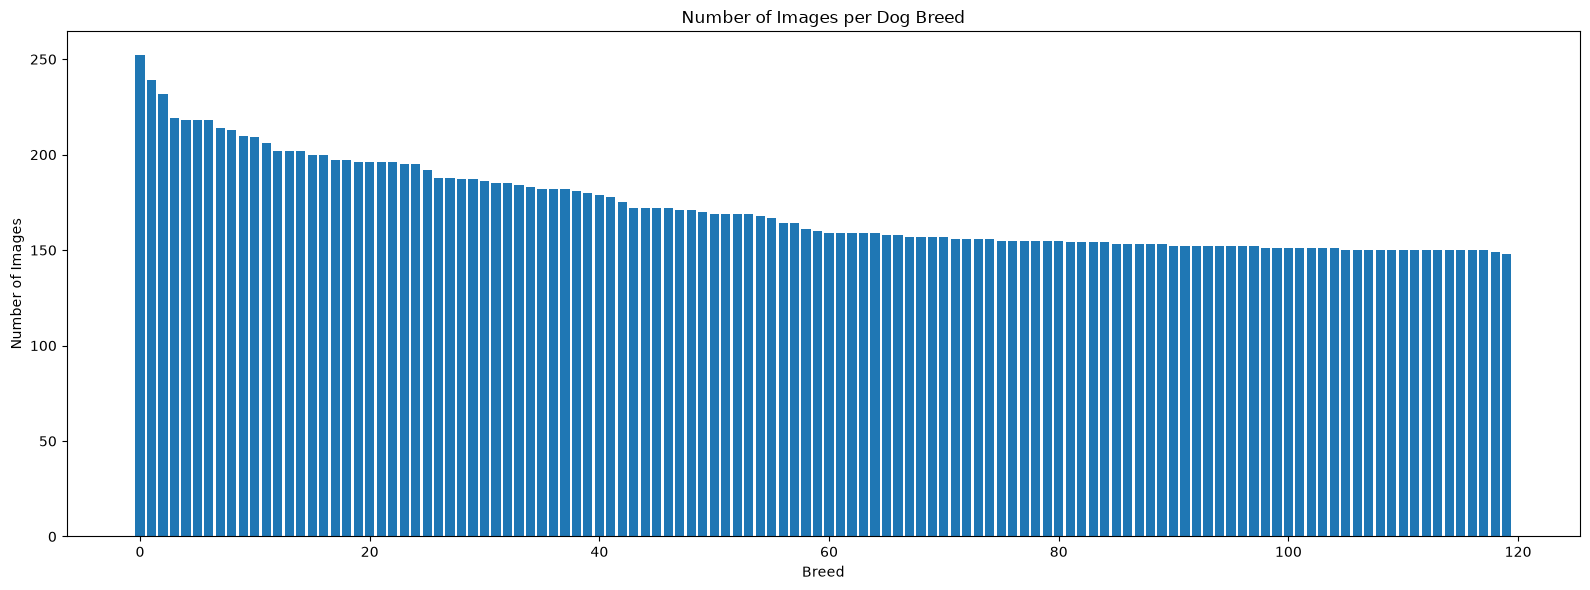

In [13]:
# Class Distribution Plot
plt.figure(figsize=(16,6))

breed_df = breed_df.sort_values("Images", ascending=False)

plt.bar(range(len(breed_df)), breed_df["Images"])

plt.title("Number of Images per Dog Breed")
plt.xlabel("Breed")
plt.ylabel("Number of Images")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- The Stanford Dogs dataset contains images from 120 dog breeds.
- Although the number of images per breed varies, the overall distribution is relatively balanced compared to many real-world datasets.
- Minor differences in class sizes are unlikely to introduce severe class imbalance during training.
- Since fine-grained classification relies on subtle visual differences rather than large class imbalance, careful preprocessing and transfer learning are expected to have a greater impact on model performance.

In [14]:
# Create a new column with the breed name
breed_df["Breed_Name"] = breed_df["Breed"].str.split("-", n=1).str[-1]
breed_df["Breed_Name"] = breed_df["Breed_Name"].str.replace("_", " ")

### Top 10 breeds with the most images

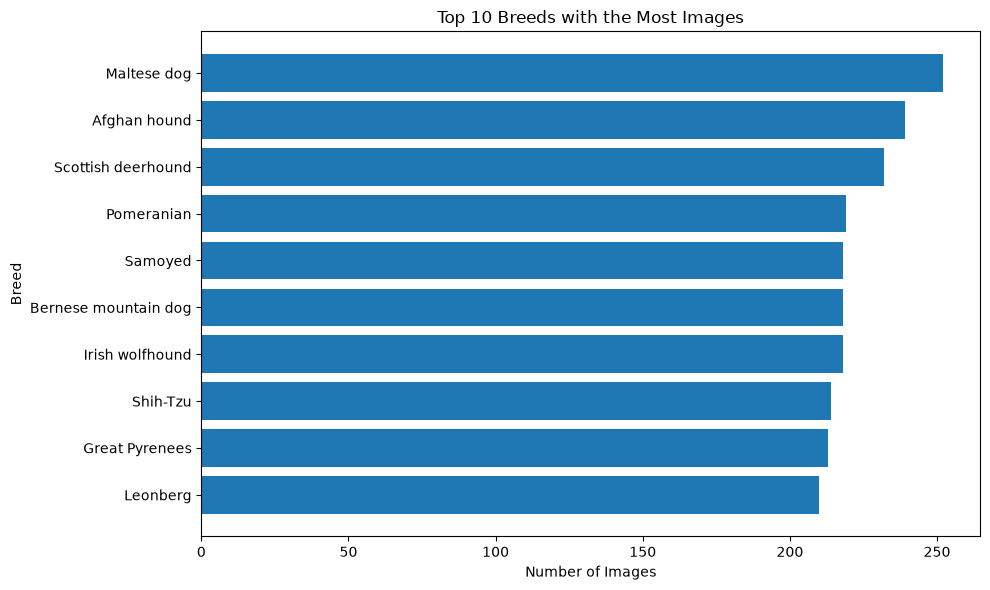

In [15]:
top_10_breeds = (
    breed_df
    .sort_values("Images", ascending=False)
    .head(10)
    .sort_values("Images", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_breeds["Breed_Name"],
    top_10_breeds["Images"]
)

plt.title("Top 10 Breeds with the Most Images")
plt.xlabel("Number of Images")
plt.ylabel("Breed")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "top_10_breeds_most_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top 10 breeds with the fewest images

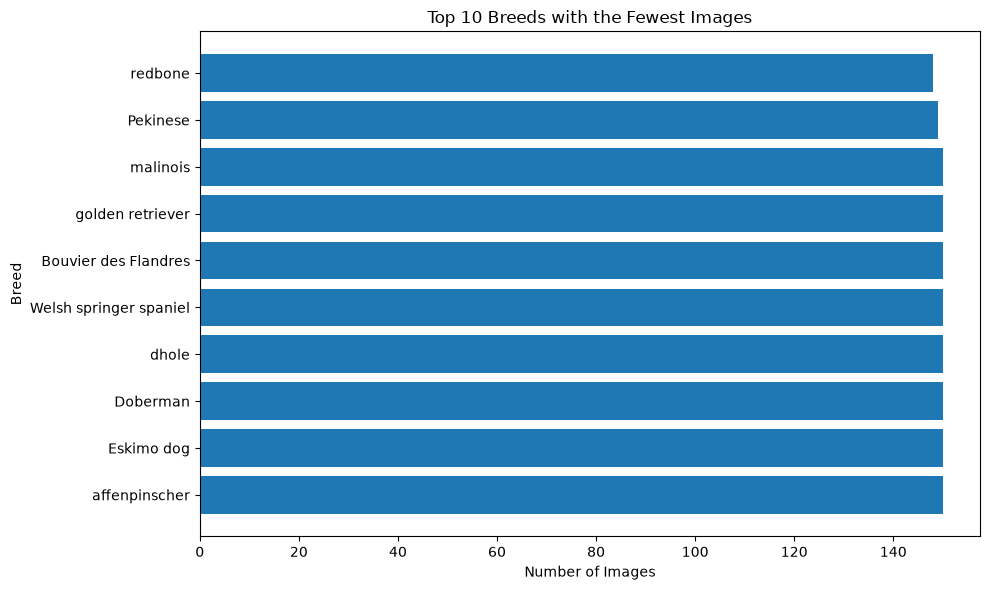

In [16]:
bottom_10_breeds = (
    breed_df
    .sort_values("Images", ascending=True)
    .head(10)
    .sort_values("Images", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    bottom_10_breeds["Breed_Name"],
    bottom_10_breeds["Images"]
)

plt.title("Top 10 Breeds with the Fewest Images")
plt.xlabel("Number of Images")
plt.ylabel("Breed")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "top_10_breeds_fewest_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Box Plot

C:\Users\soode\AppData\Local\Temp\ipykernel_48624\1776699482.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(breed_df["Images"], vert=True)


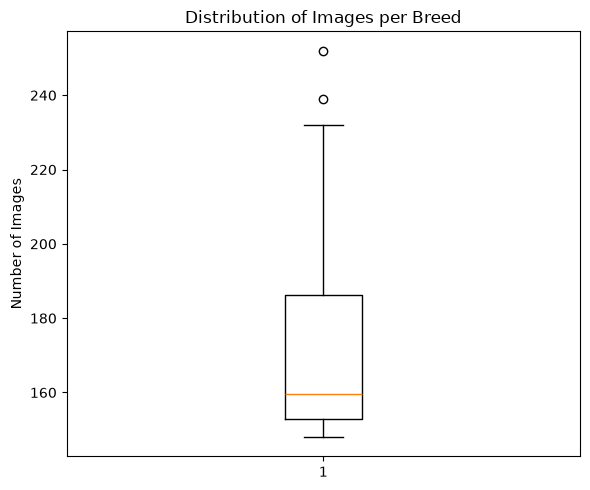

In [17]:
plt.figure(figsize=(6, 5))

plt.boxplot(breed_df["Images"], vert=True)

plt.ylabel("Number of Images")
plt.title("Distribution of Images per Breed")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "breed_distribution_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Display the exact values

In [18]:
class_extremes = pd.concat(
    [
        top_10_breeds.sort_values("Images", ascending=False).assign(
            Group="Most Images"
        ),
        bottom_10_breeds.sort_values("Images", ascending=True).assign(
            Group="Fewest Images"
        ),
    ],
    ignore_index=True,
)

class_extremes[["Group", "Breed", "Images"]]

,Group,Breed,Images
0,Most Images,n02085936-Maltese_dog,252
1,Most Images,n02088094-Afghan_hound,239
2,Most Images,n02092002-Scottish_deerhound,232
3,Most Images,n02112018-Pomeranian,219
4,Most Images,n02107683-Bernese_mountain_dog,218
5,Most Images,n02111889-Samoyed,218
6,Most Images,n02090721-Irish_wolfhound,218
7,Most Images,n02086240-Shih-Tzu,214
8,Most Images,n02111500-Great_Pyrenees,213
9,Most Images,n02111129-Leonberg,210


### Class-imbalance statistics

In [19]:
minimum_class_size = breed_df["Images"].min()
maximum_class_size = breed_df["Images"].max()
mean_class_size = breed_df["Images"].mean()
median_class_size = breed_df["Images"].median()
standard_deviation = breed_df["Images"].std()

imbalance_ratio = maximum_class_size / minimum_class_size
coefficient_of_variation = standard_deviation / mean_class_size

class_balance_summary = pd.DataFrame(
    {
        "Metric": [
            "Minimum images per breed",
            "Maximum images per breed",
            "Mean images per breed",
            "Median images per breed",
            "Standard deviation",
            "Maximum-to-minimum ratio",
            "Coefficient of variation",
        ],
        "Value": [
            minimum_class_size,
            maximum_class_size,
            round(mean_class_size, 2),
            round(median_class_size, 2),
            round(standard_deviation, 2),
            round(imbalance_ratio, 2),
            round(coefficient_of_variation, 3),
        ],
    }
)

class_balance_summary

,Metric,Value
0,Minimum images per breed,148.000
1,Maximum images per breed,252.000
2,Mean images per breed,171.500
3,Median images per breed,159.500
4,Standard deviation,23.220
5,Maximum-to-minimum ratio,1.700
6,Coefficient of variation,0.135


### Observations

- The Stanford Dogs dataset contains **120 dog breeds** represented by **20,580 images**.
- Breed sizes range from **148** to **252** images, with an average of **171.5** images per breed.
- The maximum-to-minimum class-size ratio is **1.70**, indicating only moderate variation in the number of samples across breeds.
- The coefficient of variation (13.5%) further suggests that the dataset is relatively balanced and does not exhibit severe class imbalance.
- Since the distribution of images across breeds is fairly uniform, model performance is expected to be influenced more by the visual similarity between breeds, variations in pose, lighting, background clutter, and image quality than by unequal class frequencies.
- Although extensive class-balancing techniques are unlikely to be necessary, stratified data splitting should still be used to preserve the class distribution across the training, validation, and testing datasets.

## 2. Representative Image Samples

Visualizing representative samples provides an intuitive understanding of the dataset before training a model. The Stanford Dogs dataset contains considerable variation in dog appearance, pose, scale, background, lighting conditions, and camera viewpoints.

Displaying example images helps identify potential challenges for image classification and motivates the need for preprocessing and data augmentation.

### Create a Random Sample of Images

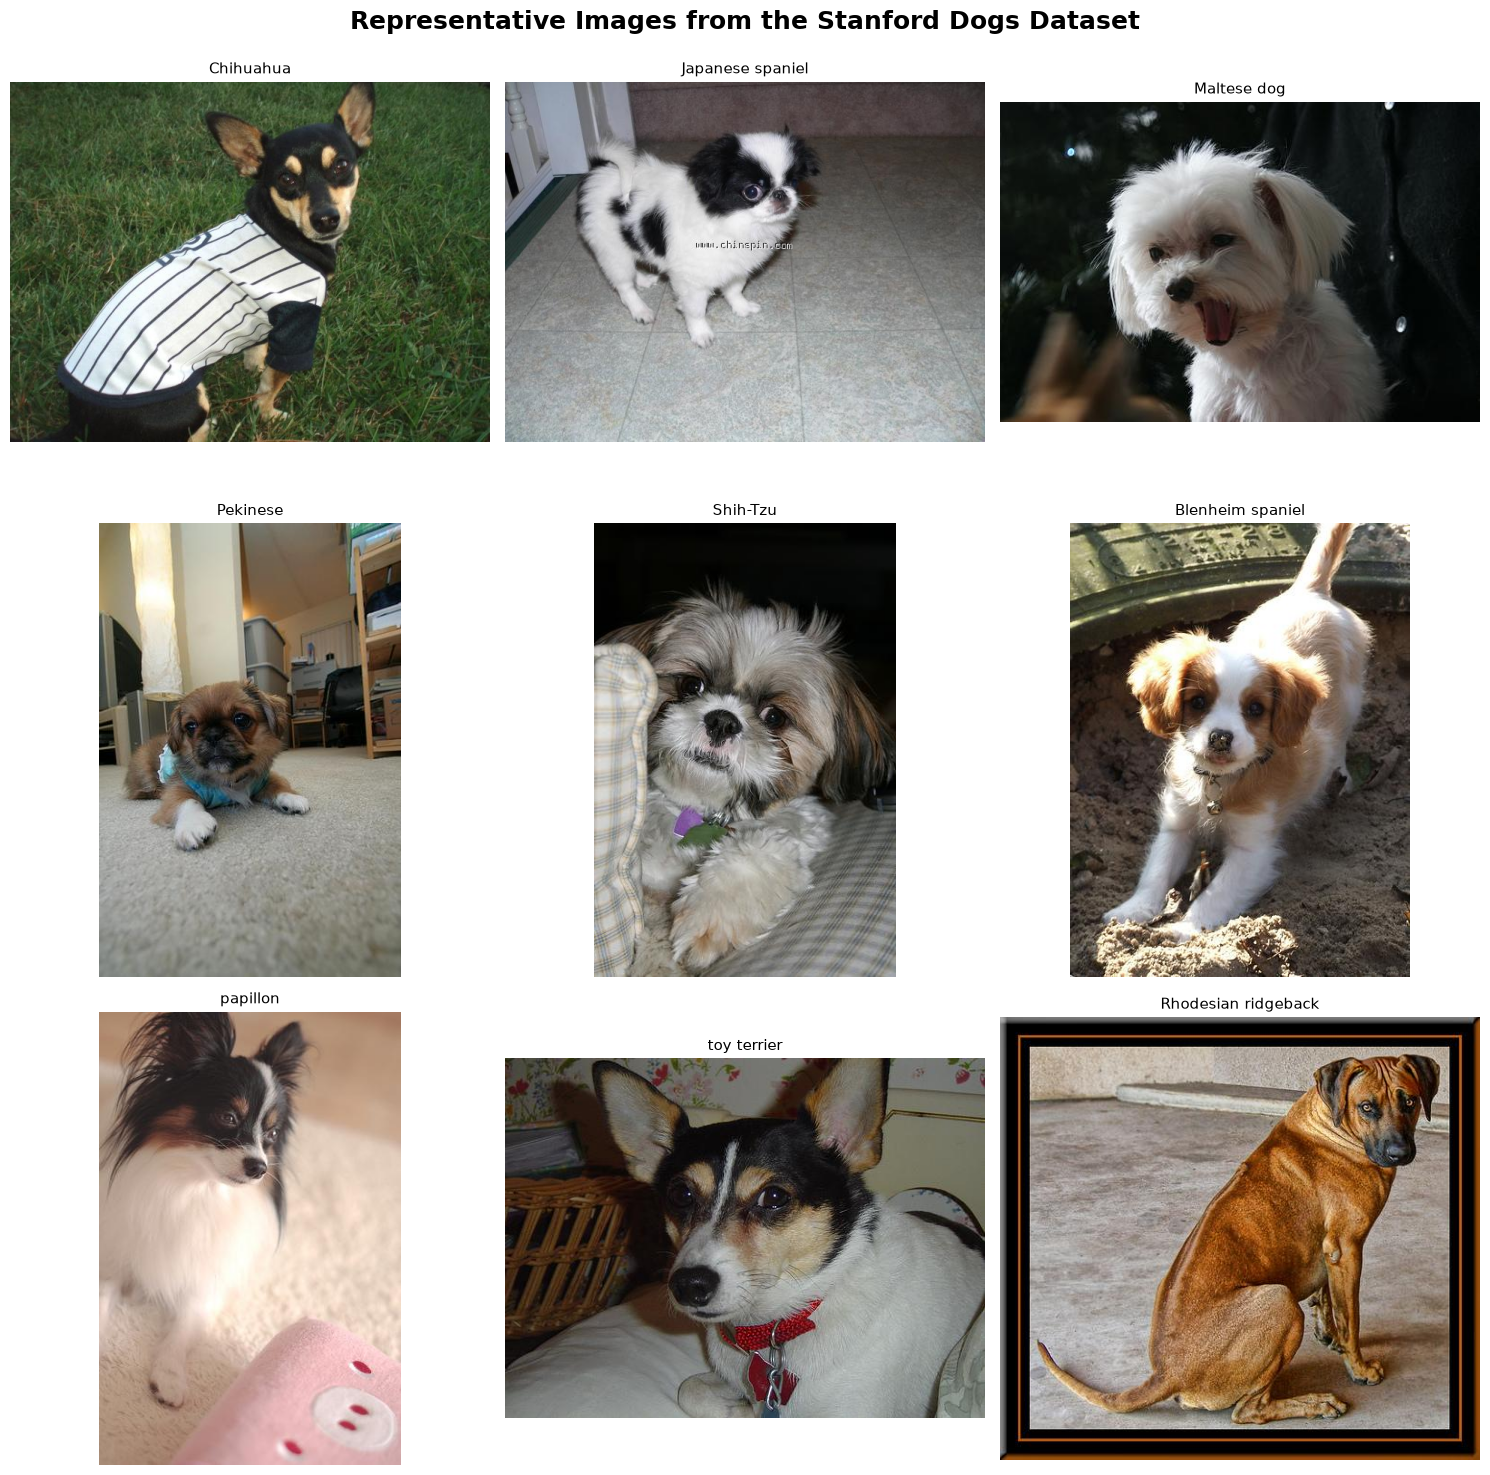

In [20]:
random.seed(42)

selected_breeds = sorted(breed_folders)[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, breed in zip(axes.flatten(), selected_breeds):

    image_files = list((IMAGES_DIR / breed).glob("*"))

    image_path = random.choice(image_files)

    image = Image.open(image_path)

    breed_name = get_breed_name(breed)

    ax.imshow(image)
    ax.set_title(breed_name, fontsize=11)
    ax.axis("off")

plt.suptitle(
    "Representative Images from the Stanford Dogs Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "representative_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Sample Image Characteristics

In [21]:
sample_information = []

for breed in selected_breeds:

    image_files = list((IMAGES_DIR / breed).glob("*"))

    image_path = random.choice(image_files)

    with Image.open(image_path) as img:

        sample_information.append(
            {
                "Breed": get_breed_name(breed),
                "Width": img.width,
                "Height": img.height,
                "Color Mode": img.mode,
            }
        )

sample_df = pd.DataFrame(sample_information)

sample_df

,Breed,Width,Height,Color Mode
0,Chihuahua,500,333,RGB
1,Japanese spaniel,435,328,RGB
2,Maltese dog,500,375,RGB
3,Pekinese,500,375,RGB
4,Shih-Tzu,500,375,RGB
5,Blenheim spaniel,500,400,RGB
6,papillon,332,500,RGB
7,toy terrier,250,285,RGB
8,Rhodesian ridgeback,500,375,RGB


### Observations

- The sampled images demonstrate substantial diversity in dog appearance across breeds.
- Dogs are photographed under different lighting conditions, camera angles, and backgrounds, increasing the complexity of the classification task.
- The position and scale of the dog within each image vary considerably, with some dogs occupying most of the frame while others appear relatively small.
- Image resolutions are not uniform, indicating that resizing will be required before model training.
- These observations support the use of preprocessing techniques such as image resizing, normalization, and data augmentation to improve model robustness and generalization.

## 3. Image Dimension Analysis

Before training a convolutional neural network (CNN), it is important to understand the dimensions of the input images. Deep learning models typically require all input images to have the same resolution, making image resizing a necessary preprocessing step.

This analysis examines the distribution of image widths, heights, and aspect ratios to better understand the variability in the dataset and to support the selection of an appropriate input size for model training.

### Collect Image Dimensions

In [22]:
# This scans every image in the dataset and stores its dimensions.
image_sizes = []

for breed in breed_folders:

    image_files = list(breed.glob("*"))

    for image_path in image_files:

        try:
            with Image.open(image_path) as img:

                image_sizes.append(
                    {
                        "Breed": get_breed_name(breed),
                        "Width": img.width,
                        "Height": img.height,
                        "Aspect Ratio": round(img.width / img.height, 3),
                    }
                )

        except Exception:
            continue

image_size_df = pd.DataFrame(image_sizes)

print(f"Images analyzed: {len(image_size_df):,}")

image_size_df.head()

Images analyzed: 20,580


,Breed,Width,Height,Aspect Ratio
0,Chihuahua,333,500,0.666
1,Chihuahua,395,495,0.798
2,Chihuahua,500,298,1.678
3,Chihuahua,345,500,0.690
4,Chihuahua,322,484,0.665


### Summary Statistics

In [23]:
image_size_df[["Width", "Height", "Aspect Ratio"]].describe()

,Width,Height,Aspect Ratio
count,20580.000000,20580.000000,20580.000000
mean,442.531876,385.861224,1.187114
std,142.792308,124.863446,0.297832
min,97.000000,100.000000,0.394000
25%,361.000000,333.000000,0.926000
50%,500.000000,375.000000,1.333000
75%,500.000000,453.000000,1.337000
max,3264.000000,2562.000000,3.634000


### Image Width Distribution

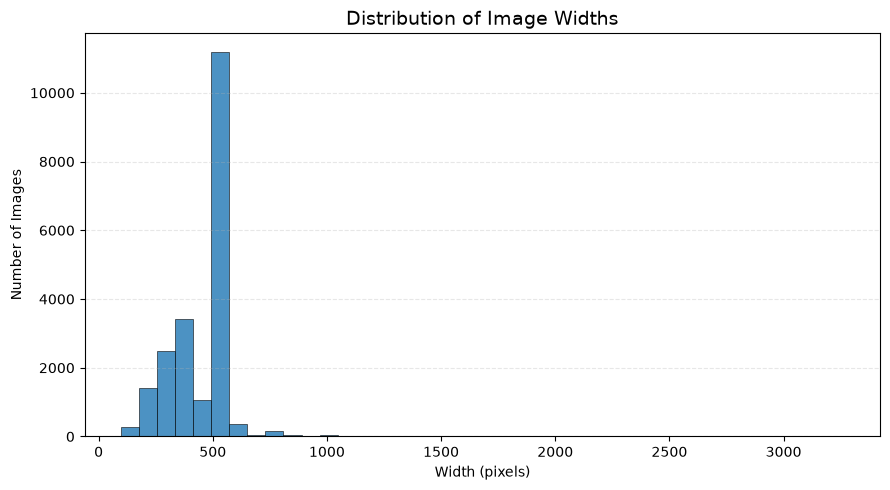

In [24]:
plt.figure(figsize=(9,5))

plt.hist(
    image_size_df["Width"],
    bins=40,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8,
)

plt.title("Distribution of Image Widths", fontsize=14)
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "image_width_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Image Height Distribution

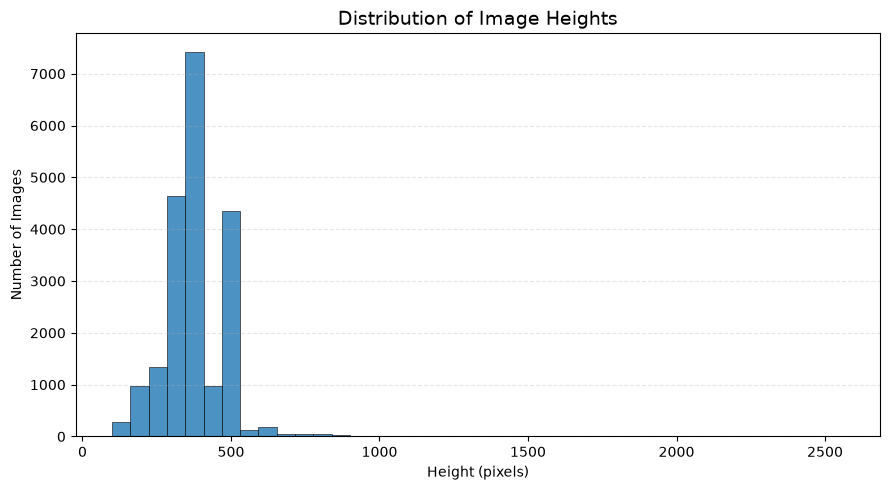

In [25]:
plt.figure(figsize=(9,5))

plt.hist(
    image_size_df["Height"],
    bins=40,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8
)

plt.title("Distribution of Image Heights", fontsize=14)
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "image_height_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Aspect Ratio Distribution

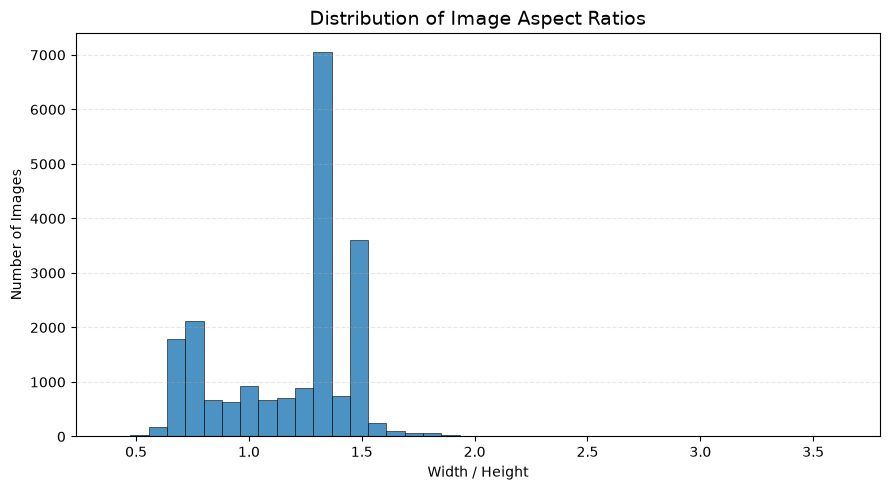

In [26]:
plt.figure(figsize=(9,5))

plt.hist(
    image_size_df["Aspect Ratio"],
    bins=40,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8
)

plt.title("Distribution of Image Aspect Ratios", fontsize=14)
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "aspect_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Image Resolution Scatter Plot

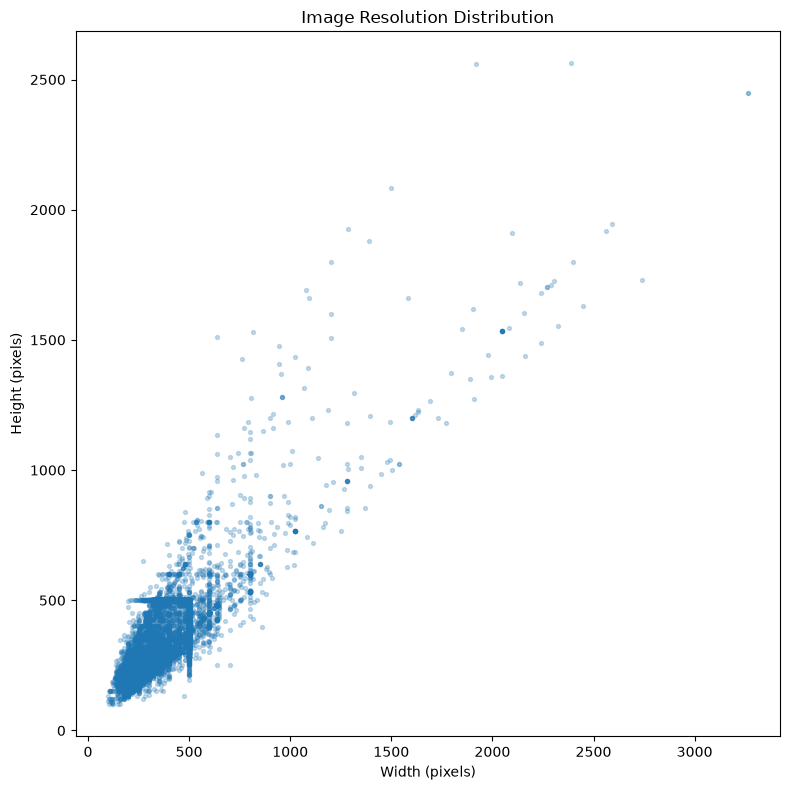

In [27]:
plt.figure(figsize=(8,8))

plt.scatter(
    image_size_df["Width"],
    image_size_df["Height"],
    alpha=0.25,
    s=8
)

plt.title("Image Resolution Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "image_resolution_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Density of Image Resolutions

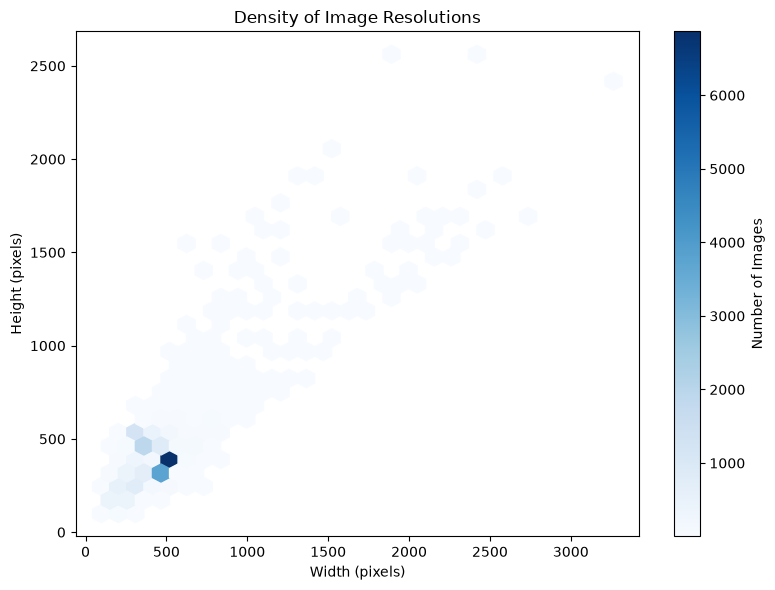

In [28]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    image_size_df["Width"],
    image_size_df["Height"],
    gridsize=30,
    cmap="Blues",
    mincnt=1
)

plt.colorbar(label="Number of Images")

plt.title("Density of Image Resolutions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "image_resolution_density.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Resolution Summary Statistics

In [29]:
summary_dimensions = pd.DataFrame(
    {
        "Metric": [
            "Minimum Width",
            "Maximum Width",
            "Average Width",
            "Minimum Height",
            "Maximum Height",
            "Average Height",
            "Minimum Aspect Ratio",
            "Maximum Aspect Ratio",
            "Average Aspect Ratio",
        ],
        "Value": [
            image_size_df["Width"].min(),
            image_size_df["Width"].max(),
            round(image_size_df["Width"].mean(),2),

            image_size_df["Height"].min(),
            image_size_df["Height"].max(),
            round(image_size_df["Height"].mean(),2),

            round(image_size_df["Aspect Ratio"].min(),2),
            round(image_size_df["Aspect Ratio"].max(),2),
            round(image_size_df["Aspect Ratio"].mean(),2),
        ]
    }
)

summary_dimensions

,Metric,Value
0,Minimum Width,97.00
1,Maximum Width,3264.00
2,Average Width,442.53
3,Minimum Height,100.00
4,Maximum Height,2562.00
5,Average Height,385.86
6,Minimum Aspect Ratio,0.39
7,Maximum Aspect Ratio,3.63
8,Average Aspect Ratio,1.19


### Observations

- Image resolutions vary considerably across the dataset, ranging from **97 × 100 pixels** to **3264 × 2562 pixels**.
- The average image size is approximately **443 × 386 pixels**, indicating that most images have moderate resolution suitable for deep learning after resizing.
- The scatter plot demonstrates a strong positive relationship between image width and height, suggesting that images generally preserve their original aspect ratios rather than being arbitrarily resized.
- Most aspect ratios are concentrated around **1.2**, although the dataset includes both portrait and landscape images. The aspect ratio ranges from **0.39** to **3.63**, indicating substantial variation in image orientation.
- The presence of multiple image resolutions and aspect ratios confirms that preprocessing is required before training. Images should be resized to a fixed input resolution while maintaining sufficient visual detail.
- Resizing all images to **224 × 224 pixels** is appropriate because it matches the expected input size of the pretrained **ResNet-18** architecture selected for this project.

## 4. Bounding Box Annotation Analysis

The Stanford Dogs dataset provides bounding-box annotations for every image. These annotations identify the region containing the dog while excluding unnecessary background information.

Bounding boxes are useful for understanding the dataset and can support preprocessing techniques such as cropping the object of interest before resizing. This may reduce background noise and help the model focus on the most informative visual features.

This section compares original images with their annotated dog regions.

### Helper Function to Read Bounding Boxes

In [30]:
def load_bounding_box(annotation_path):
    """
    Read a Stanford Dogs XML annotation file and return
    xmin, ymin, xmax, ymax.
    """
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    bbox = root.find(".//bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    return xmin, ymin, xmax, ymax

### Find an Example Image

In [31]:
# Load an example image and its annotation
example_breed = sorted(breed_folders)[0]

example_image = sorted(example_breed.glob("*"))[0]

annotation_file = (
    ANNOTATIONS_DIR
    / example_breed.name
    / example_image.stem
)

print(example_image.name)
print(annotation_file)

n02085620_10074.jpg
c:\Users\soode\OneDrive\Documents\Summer 2026\MAI202 - DL\Project Folder\dog-breed-ood-detector\data\raw\Annotation\n02085620-Chihuahua\n02085620_10074


### Load the Image

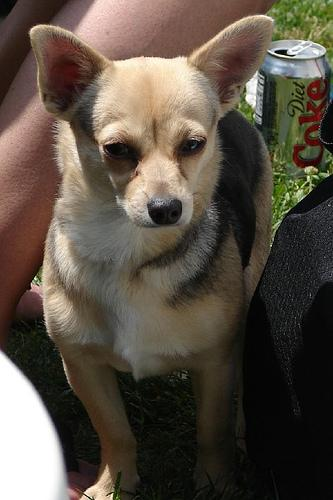

In [32]:
image = Image.open(example_image)

xmin, ymin, xmax, ymax = load_bounding_box(annotation_file)

image

### Draw the Bounding Box

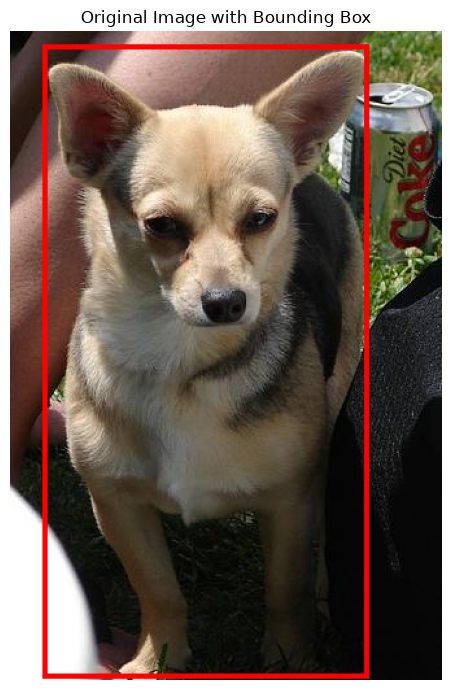

In [33]:
boxed_image = image.copy()

draw = ImageDraw.Draw(boxed_image)

draw.rectangle(
    [(xmin, ymin), (xmax, ymax)],
    outline="red",
    width=4,
)

plt.figure(figsize=(7,7))

plt.imshow(boxed_image)

plt.title("Original Image with Bounding Box")

plt.axis("off")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "bounding_box_example.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Crop the Dog

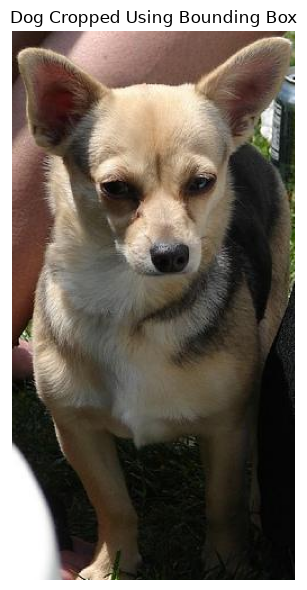

In [34]:
cropped_image = image.crop((xmin, ymin, xmax, ymax))

plt.figure(figsize=(6,6))

plt.imshow(cropped_image)

plt.title("Dog Cropped Using Bounding Box")

plt.axis("off")

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "cropped_dog_example.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Side-by-Side Comparison

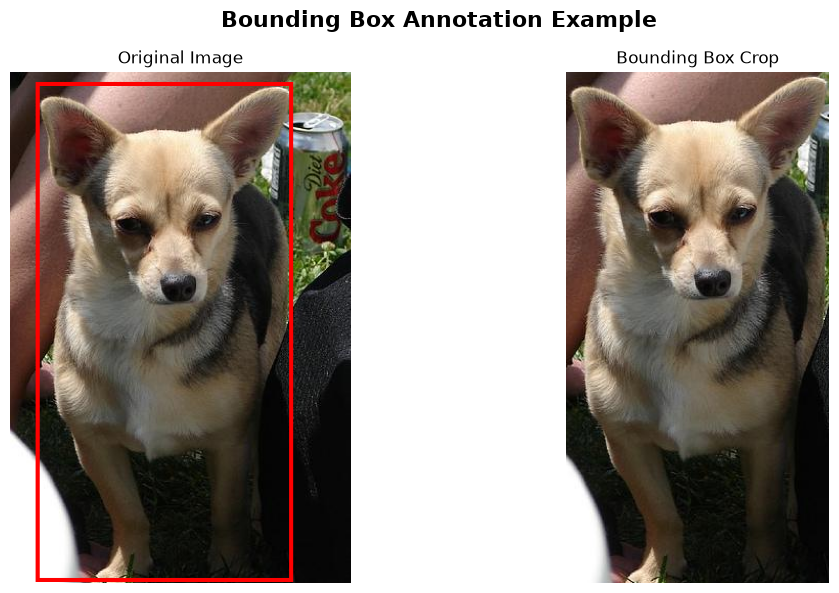

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].imshow(boxed_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cropped_image)
axes[1].set_title("Bounding Box Crop")
axes[1].axis("off")

plt.suptitle(
    "Bounding Box Annotation Example",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "bounding_box_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Observations

- The provided annotations accurately localize the dog within each image.
- Cropping the image removes much of the surrounding background while preserving the primary object of interest.
- Background removal can reduce irrelevant visual information and potentially improve feature extraction during training.
- For this project, the original images will be used for model training to preserve contextual information and maintain consistency with standard benchmark practices. However, the available annotations could support future experiments comparing classification performance with and without background cropping.

### Select Three Breeds

In [36]:
random.seed(42)

selected_breeds = random.sample(breed_folders, 3)

### Create the Visualization

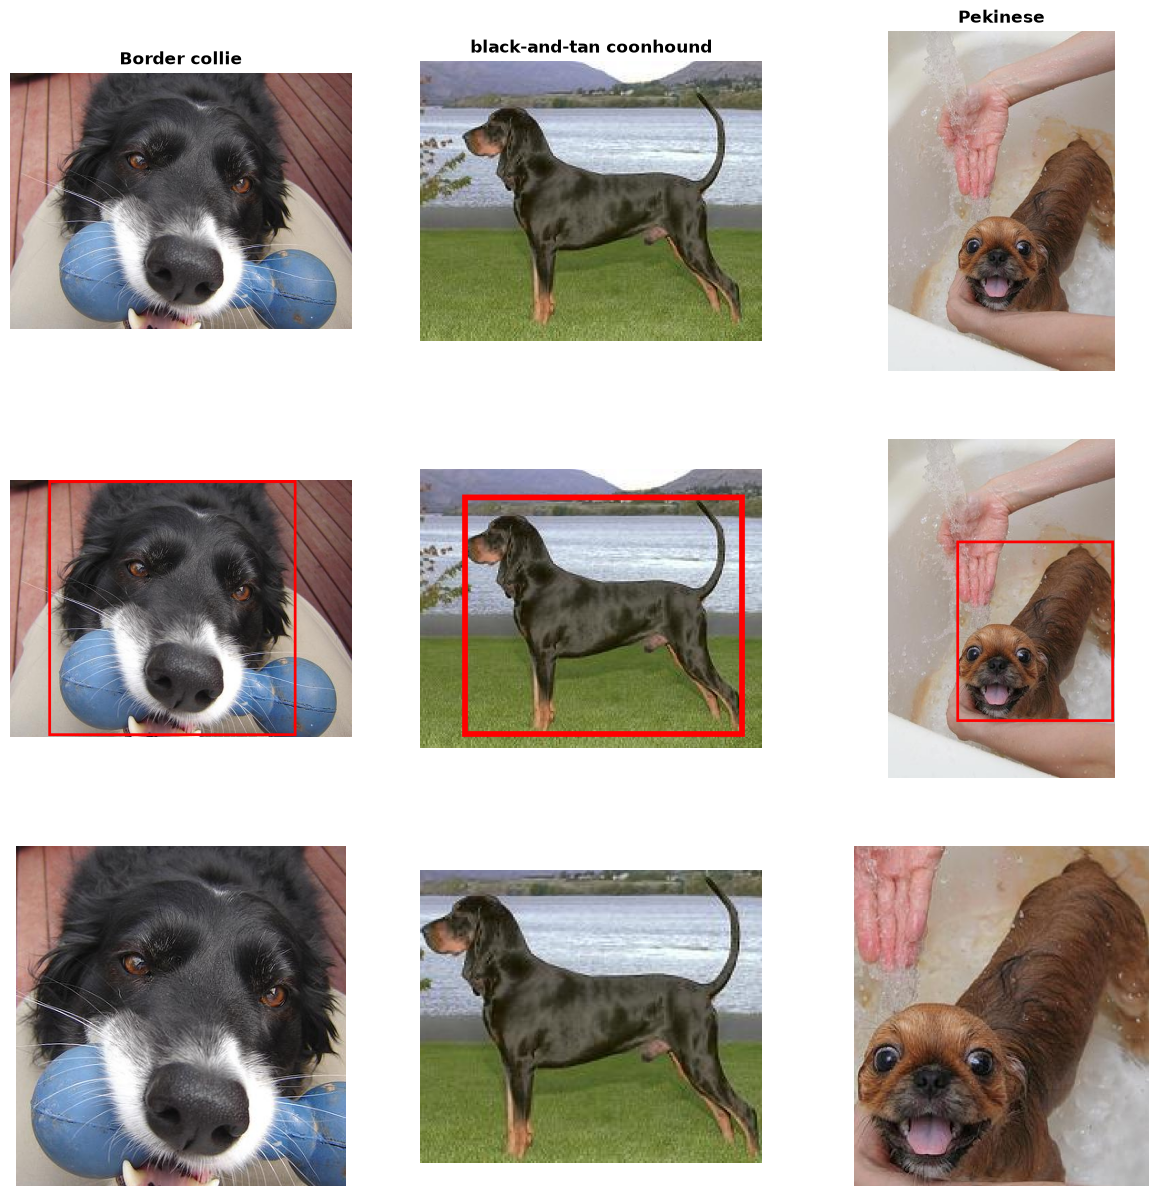

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for column, breed in enumerate(selected_breeds):

    image_path = random.choice(list(breed.glob("*")))

    annotation_path = (
        ANNOTATIONS_DIR
        / breed.name
        / image_path.stem
    )

    image = Image.open(image_path)

    xmin, ymin, xmax, ymax = load_bounding_box(annotation_path)

    boxed_image = image.copy()

    draw = ImageDraw.Draw(boxed_image)

    draw.rectangle(
        [(xmin, ymin), (xmax, ymax)],
        outline="red",
        width=4,
    )

    cropped_image = image.crop(
        (xmin, ymin, xmax, ymax)
    )

    breed_name = get_breed_name(breed)

    # ------------------------
    # Original Image
    # ------------------------

    axes[0, column].imshow(image)
    
    for spine in axes[0, column].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        
    axes[0, column].set_title(
        breed_name,
        fontsize=12,
        fontweight="bold",
    )
    axes[0, column].axis("off")
    
    # ------------------------
    # Bounding Box
    # ------------------------

    axes[1, column].imshow(boxed_image)
    
    for spine in axes[1, column].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        
    axes[1, column].axis("off")

    # ------------------------
    # Cropped Image
    # ------------------------

    axes[2, column].imshow(cropped_image)
    
    for spine in axes[2, column].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        
    axes[2, column].axis("off")

### Add Row Labels

In [38]:
axes[0,0].set_ylabel(
    "Original",
    fontsize=13,
    fontweight="bold",
)

axes[1,0].set_ylabel(
    "Bounding Box",
    fontsize=13,
    fontweight="bold",
)

axes[2,0].set_ylabel(
    "Cropped Dog",
    fontsize=13,
    fontweight="bold",
)

Text(0, 0.5, 'Cropped Dog')

### Finish the Figure

In [39]:
plt.suptitle(
    "Bounding Box Annotation Examples",
    fontsize=18,
    fontweight="bold",
)

plt.tight_layout()

plt.savefig(
    EDA_PLOTS_DIR / "bounding_box_examples.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

<Figure size 640x480 with 0 Axes>

### Observations

- The annotation files accurately identify the location of the dog across different breeds, poses, and backgrounds.
- Bounding-box cropping removes a large portion of the surrounding scene while preserving the primary object of interest.
- Several examples demonstrate that the annotations remain reliable despite considerable variation in camera angle, illumination, image scale, and background complexity.
- The cropped images highlight the visual characteristics that distinguish one breed from another while reducing potentially distracting background information.
- Although this project uses the original images for consistency with standard image classification benchmarks, the provided annotations offer an opportunity for future experiments comparing full-image classification with object-focused classification.

# 5. EDA Summary and Preprocessing Recommendations

The exploratory data analysis provides valuable insights into the characteristics of the Stanford Dogs dataset and identifies important considerations for model development. Based on the analyses performed throughout this notebook, several preprocessing decisions can be justified before training deep learning models.

### Summary Table

In [40]:
eda_summary = pd.DataFrame({
    "EDA Finding": [
        "Number of classes",
        "Dataset size",
        "Class distribution",
        "Image resolution",
        "Aspect ratios",
        "Bounding-box annotations",
        "Visual variability"
    ],
    "Observation": [
        "120 dog breeds",
        "20,580 images",
        "Relatively balanced (CV = 13.5%)",
        "97×100 to 3264×2562 pixels",
        "Wide range (0.39–3.63)",
        "Available for every image",
        "Large variation in pose, lighting and background"
    ],
    "Impact on Model Development": [
        "Multi-class classification problem",
        "Sufficient data for transfer learning",
        "No major class balancing required",
        "Images must be resized",
        "Careful preprocessing required",
        "Can support future cropping experiments",
        "Data augmentation is recommended"
    ]
})

eda_summary

,EDA Finding,Observation,Impact on Model Development
0,Number of classes,120 dog breeds,Multi-class classification problem
1,Dataset size,"20,580 images",Sufficient data for transfer learning
2,Class distribution,Relatively balanced (CV = 13.5%),No major class balancing required
3,Image resolution,97×100 to 3264×2562 pixels,Images must be resized
4,Aspect ratios,Wide range (0.39–3.63),Careful preprocessing required
5,Bounding-box annotations,Available for every image,Can support future cropping experiments
6,Visual variability,"Large variation in pose, lighting and background",Data augmentation is recommended


## Preprocessing Recommendations

Based on the exploratory data analysis, the following preprocessing recommendations should be considered during model development:

- Resize all images to **224 × 224 pixels** to match the input requirements of pretrained convolutional neural networks.
- Normalize pixel values using the preprocessing pipeline required by the selected pretrained architecture.
- Apply data augmentation techniques such as random horizontal flipping, random cropping, rotation, and color jitter during training to improve generalization.
- Preserve the original class distribution by using stratified train, validation, and test splits.
- Consider using the original images for the baseline while retaining the bounding-box annotations for possible comparisons between full-image and object-focused classification.

## Conclusions

The Stanford Dogs dataset is well suited for fine-grained image classification research. Although the dataset exhibits considerable variability in image resolution, aspect ratio, lighting conditions, backgrounds, and viewing angles, the overall class distribution is relatively balanced across the 120 breeds.

The exploratory data analysis indicates that the primary challenge is not class imbalance but rather the visual similarity between different dog breeds. Consequently, model performance is expected to depend more heavily on effective feature extraction, transfer learning, and robust data augmentation than on class-balancing techniques.

The findings from this analysis establish a strong foundation for the subsequent stages of the project, including data preprocessing, model training, and performance evaluation.

## Key Findings for Model Training

The exploratory data analysis led to several important conclusions that directly influence the design of the image classification pipeline:

- The dataset is relatively balanced; therefore, extensive class-balancing techniques are unnecessary.
- Images vary considerably in resolution and aspect ratio, making resizing an essential preprocessing step.
- Bounding-box annotations provide opportunities for future object-focused preprocessing experiments.
- Large variations in background, illumination, and pose motivate the use of data augmentation.
- Because the primary challenge is distinguishing visually similar dog breeds, transfer learning with pretrained CNNs is expected to be more effective than training a model from scratch.

---

**End of Exploratory Data Analysis**

The insights obtained from this analysis will guide the preprocessing pipeline and the development of the image classification models in the subsequent stages of the project.
This notebook establishes the baseline understanding of the Stanford Dogs dataset and provides the rationale for the preprocessing pipeline that will be implemented during model development.